In [1]:
using Pkg
Pkg.activate("/home/gridsan/aligho/Github_Projects/JJDFTX.jl/")
ENV["JULIA_REVISE_POLL"]="1";
using Revise

In [2]:
using PyPlot, PyCall, Peaks, Statistics, JJDFTX, LinearAlgebra, StatsBase;

┌ Info: Precompiling JJDFTX [0d21db8c-e7cb-497b-98f4-4306b49e2569]
└ @ Base loading.jl:1317


Your version of python is not linked to helper_scripts.py
Your version of python is not linked to the Atomic Simulation Environment


In [3]:
readdir()
li_dir="./Lithium"
na_dir="./Sodium"
k_dir="./Potassium"
rb_dir="./Rubidium"
cs_dir="./Cesium"

"./Cesium"

In [4]:
Na_Energies=zeros(100)
Na_dists=zeros(100)
for i in 1:100
    Na_Energies[i] = list_energy("$na_dir/Sodium-$i.out")
    Na_dists[i] = get_d("$na_dir/Sodium-$i.out", "Na")
end

Li_Energies=zeros(100)
Li_dists=zeros(100)
for i in 1:100
    Li_Energies[i] = list_energy("$li_dir/Lithium-$i.out")
    Li_dists[i] = get_d("$li_dir/Lithium-$i.out", "Li")
end

K_Energies=zeros(100)
K_dists=zeros(100)
for i in 1:100
    K_Energies[i] = list_energy("$k_dir/Potassium-$i.out")
    K_dists[i] = get_d("$k_dir/Potassium-$i.out", "K")

end

Rb_Energies=zeros(100)
Rb_dists=zeros(100)
for i in 1:100
    Rb_Energies[i] = list_energy("$rb_dir/Rubidium-$i.out")
    Rb_dists[i] = get_d("$rb_dir/Rubidium-$i.out", "Rb")
end

Cs_Energies=zeros(100)
Cs_dists=zeros(100)
for i in 1:100
    Cs_Energies[i] = list_energy("$cs_dir/Cesium-$i.out")
    Cs_dists[i] = get_d("$cs_dir/Cesium-$i.out", "Cs")
end

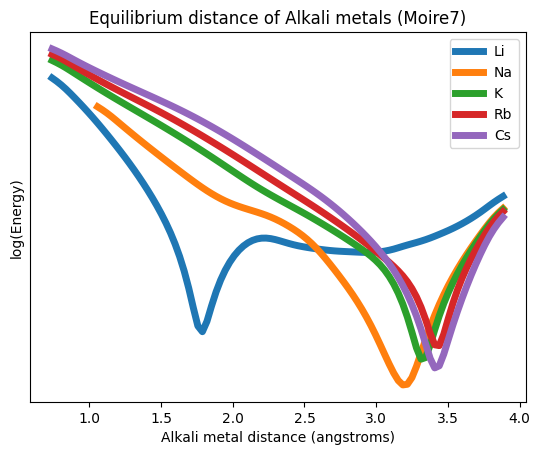

PyObject <matplotlib.legend.Legend object at 0x7fba783d70d0>

In [7]:
plot(Li_dists, log.(smooth(Li_Energies, win_len=10) .- minimum(Li_Energies) .+ 0.001), linewidth=5, label="Li")
plot(Na_dists[1:90], log.(smooth(Na_Energies[1:90], win_len=10) .- minimum(Na_Energies) .+ 0.001), linewidth=5, label="Na")
plot(K_dists, log.(smooth(K_Energies, win_len=10) .- minimum(K_Energies) .+ 0.0001), linewidth=5, label="K")
plot(Rb_dists, log.(smooth(Rb_Energies, win_len=10) .- minimum(Rb_Energies) .+ 0.001), linewidth=5, label="Rb")
plot(Cs_dists, log.(smooth(Cs_Energies, win_len=10) .- minimum(Cs_Energies) .+ 0.001), linewidth=5, label="Cs")
xlabel("Alkali metal distance (angstroms)")
title("Equilibrium distance of Alkali metals (Moire7)")
yticks([])
ylabel("log(Energy)")
legend()

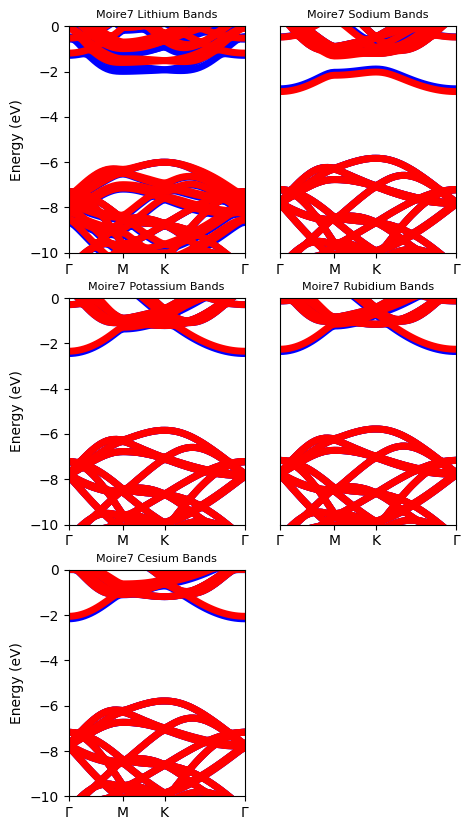

(-10.0, 0.0)

In [41]:
figure(figsize=(5, 10))
subplot(3, 2, 1)
plot_bands("$li_dir/Li-bands-0.169.eigenvals", spin=2, to_greek=true)
title("Moire7 Lithium Bands", fontsize=8)
xlabel("")
ylim(-10, 0)
subplot(3, 2, 2)
plot_bands("$na_dir/Na-bands-0.307.eigenvals", spin=2, to_greek=true)
title("Moire7 Sodium Bands", fontsize=8)
xlabel("")
yticks([])
ylabel("")
ylim(-10, 0)
subplot(3, 2, 3)
plot_bands("$k_dir/K-bands-0.313.eigenvals", spin=2, to_greek=true)
title("Moire7 Potassium Bands", fontsize=8)
xlabel("")
ylim(-10, 0)
subplot(3, 2, 4)
plot_bands("$rb_dir/Rb-bands-0.325.eigenvals", spin=2, to_greek=true)
title("Moire7 Rubidium Bands", fontsize=8)
xlabel("")
yticks([])
ylabel("")
ylim(-10, 0)
subplot(3, 2, 5)
plot_bands("$cs_dir/Cs-bands-0.325.eigenvals", spin=2, to_greek=true)
title("Moire7 Cesium Bands", fontsize=8)
xlabel("")
ylim(-10, 0)


In [23]:
figure(figsize=(10, 10))
subplot(3, 2, 1)
plot_bands("$li_dir/Li-bands-0.169.eigenvals", spin=2, to_greek=true)
title("Moire7 Lithium Bands", fontsize=8)
xlabel("")
ylim(-10, 0)
subplot(3, 2, 2)
plot_bands("$na_dir/Na-bands-0.307.eigenvals", spin=2, to_greek=true)
title("Moire7 Sodium Bands", fontsize=8)
xlabel("")
ylim(-10, 0)
subplot(3, 2, 3)
plot_bands("$k_dir/K-bands-0.313.eigenvals", spin=2, to_greek=true)
title("Moire7 Potassium Bands", fontsize=8)
xlabel("")
ylim(-10, 0)
subplot(3, 2, 4)
plot_bands("$rb_dir/Rb-bands-0.325.eigenvals", spin=2, to_greek=true)
title("Moire7 Rubidium Bands", fontsize=8)
xlabel("")
ylim(-10, 0)
subplot(3, 2, 5)
plot_bands("$cs_dir/Cs-bands-0.325.eigenvals", spin=2, to_greek=true)
title("Moire7 Cesium Bands", fontsize=8)
xlabel("")
ylim(-10, 0)


86

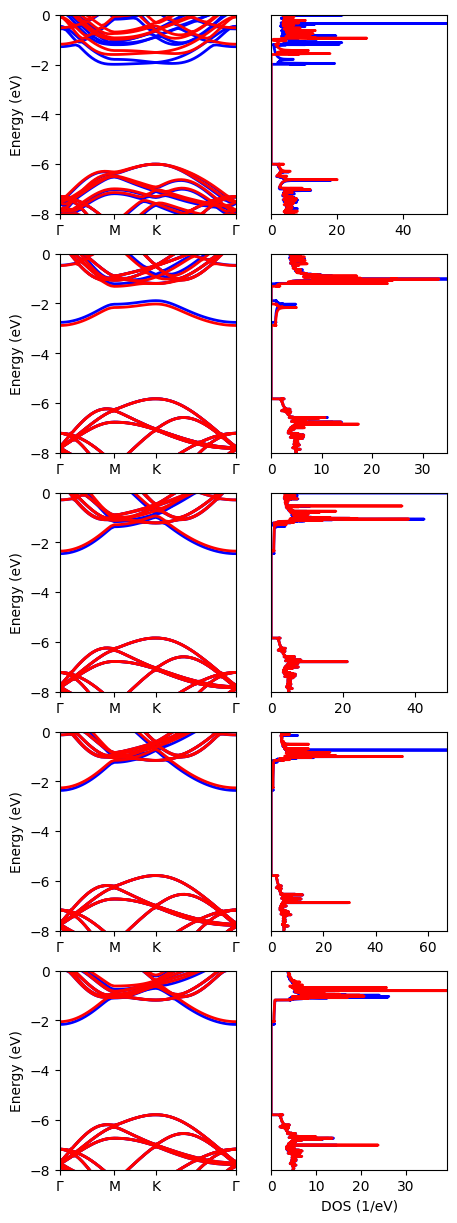

PyObject Text(0.5, 262.96551724137936, '')

In [57]:
figure(figsize=(5, 15))
bands_overlayed_dos("$li_dir/dos/Li-0.169.dosUp", "$li_dir/dos/Li-0.169.dosDn", "$li_dir/Li-bands-0.169.eigenvals"
, energy_range=(-8, 0), band_subplot=[5, 2, 1], dos_subplot=[5, 2, 2], dos_yticks=false)
bands_overlayed_dos("$na_dir/dos/Na-0.307.dosUp", "$na_dir/dos/Na-0.307.dosDn", "$na_dir/Na-bands-0.307.eigenvals"
, energy_range=(-8, 0), band_subplot=[5, 2, 3], dos_subplot=[5, 2, 4], dos_yticks=false)
bands_overlayed_dos("$k_dir/dos/K-0.313.dosUp", "$k_dir/dos/K-0.313.dosDn", "$k_dir/K-bands-0.313.eigenvals"
, energy_range=(-8, 0), band_subplot=[5, 2, 5], dos_subplot=[5, 2, 6], dos_yticks=false)
bands_overlayed_dos("$rb_dir/dos/Rb-0.325.dosUp", "$rb_dir/dos/Rb-0.325.dosDn", "$rb_dir/Rb-bands-0.325.eigenvals"
, energy_range=(-8, 0), band_subplot=[5, 2, 7], dos_subplot=[5, 2, 8], dos_yticks=false)
bands_overlayed_dos("$cs_dir/dos/Cs-0.325.dosUp", "$cs_dir/dos/Cs-0.325.dosDn", "$cs_dir/Cs-bands-0.325.eigenvals"
, energy_range=(-8, 0), band_subplot=[5, 2, 9], dos_subplot=[5, 2, 10], dos_yticks=false)

subplot(5, 2, 2)
xlabel("")
subplot(5, 2, 4)
xlabel("")
subplot(5, 2, 6)
xlabel("")
subplot(5, 2, 8)
xlabel("")

In [17]:
8*2*7+5

117